In [22]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import scipy.signal as sig

In [23]:
N = 100 #Number of keys
keys = np.arange(1, N, 1)

notes = (np.power(2, (1/12)))**(keys-49)*440 # Frequencies of each notes

In [24]:
sample_path = "sample_1.mp3"
audio_signal, sample_rate = librosa.load(sample_path, sr=None, mono=False)

if audio_signal.ndim > 1:
    audio_signal = audio_signal[0, :]

cutoff_frequency = 5000 
nyquist = 2.0 * sample_rate 
normal_cutoff = cutoff_frequency / nyquist 

b, a = sig.butter(N=4, Wn=normal_cutoff, btype='low', analog=False)
filtered_signal = sig.filtfilt(b, a, audio_signal)

time = librosa.times_like(audio_signal, sr=sample_rate)

In [25]:
# Compute onset envelope
onset_env = librosa.onset.onset_strength(y=audio_signal, sr=sample_rate)

# Detect onset times
onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sample_rate)
onset_times = librosa.frames_to_time(onset_frames, sr=sample_rate)

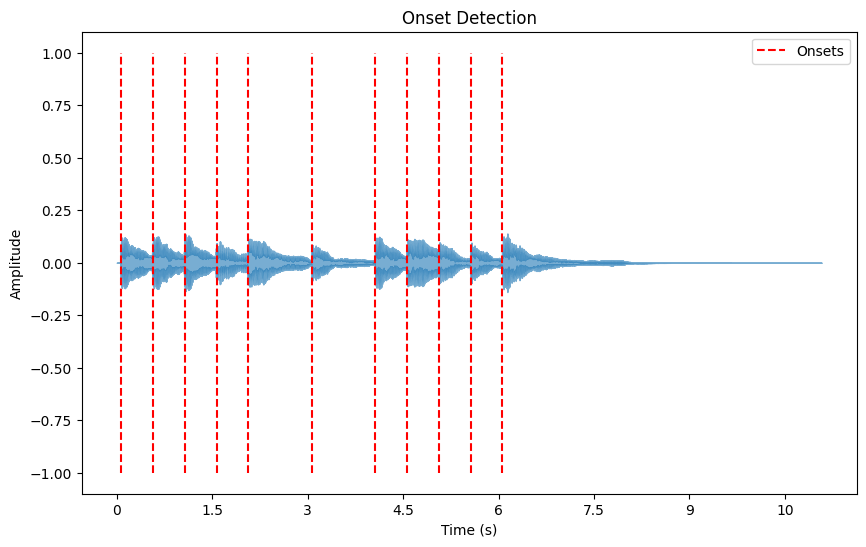

Onset times (in seconds): [0.05804989 0.56888889 1.06811791 1.56734694 2.06657596 3.06503401
 4.06349206 4.56272109 5.06195011 5.56117914 6.06040816]


In [26]:
# Plot the signal and onsets
plt.figure(figsize=(10, 6))
librosa.display.waveshow(audio_signal, sr=sample_rate, alpha=0.6)
plt.vlines(onset_times, -1, 1, color='r', linestyle='--', label='Onsets')
plt.title('Onset Detection')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# Print onset times
print("Onset times (in seconds):", onset_times)

In [27]:
# Segment the signal based on onset times
onset_samples = librosa.time_to_samples(onset_times, sr=sample_rate)
segments = [audio_signal[onset_samples[i]:onset_samples[i+1]] for i in range(len(onset_samples)-1)]

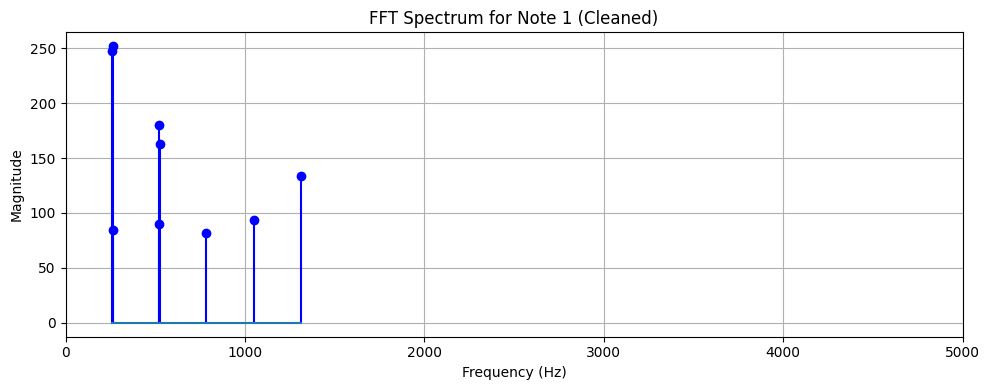

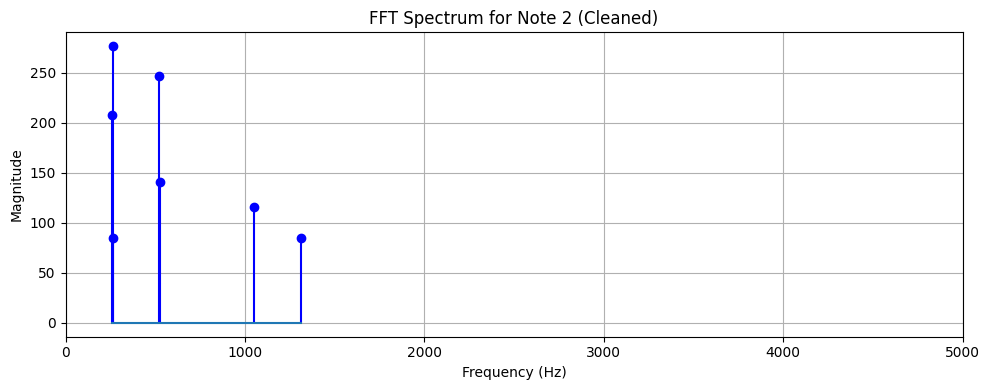

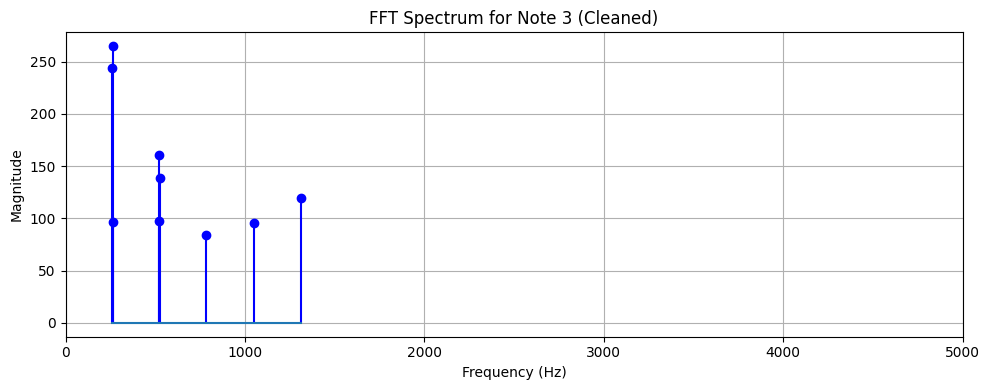

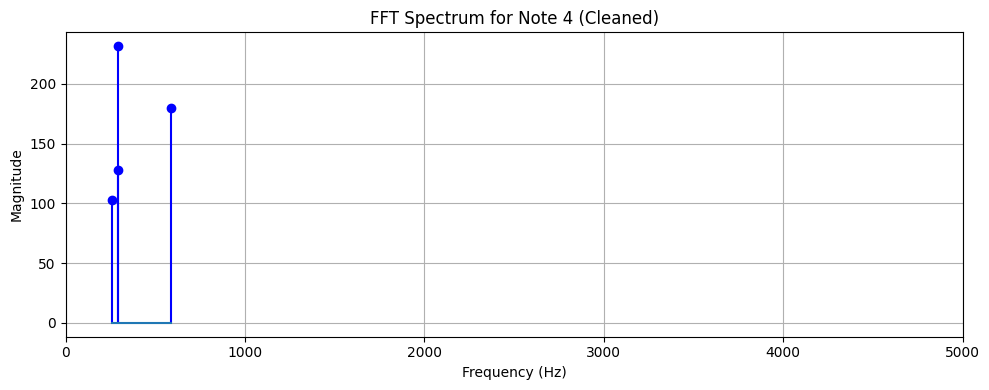

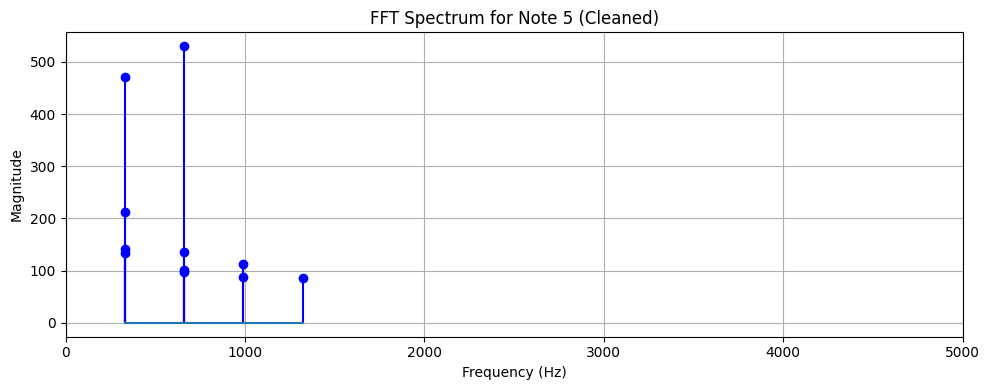

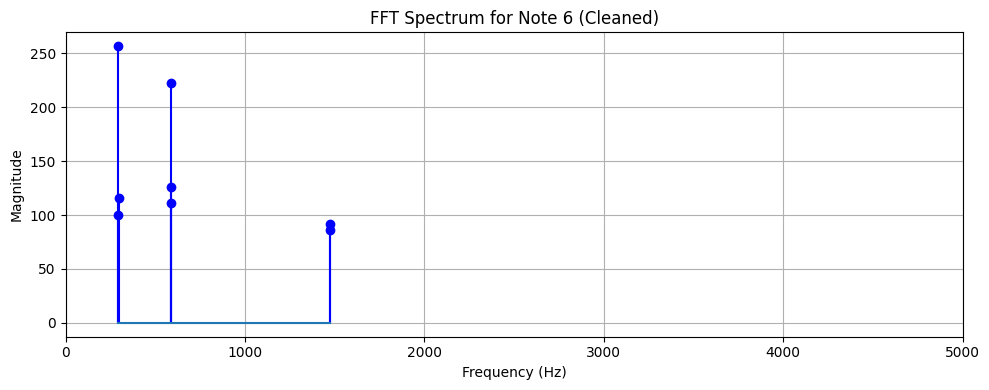

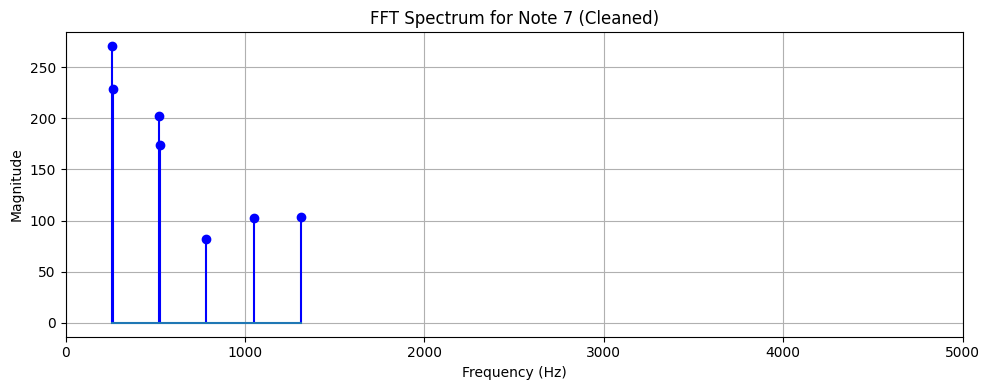

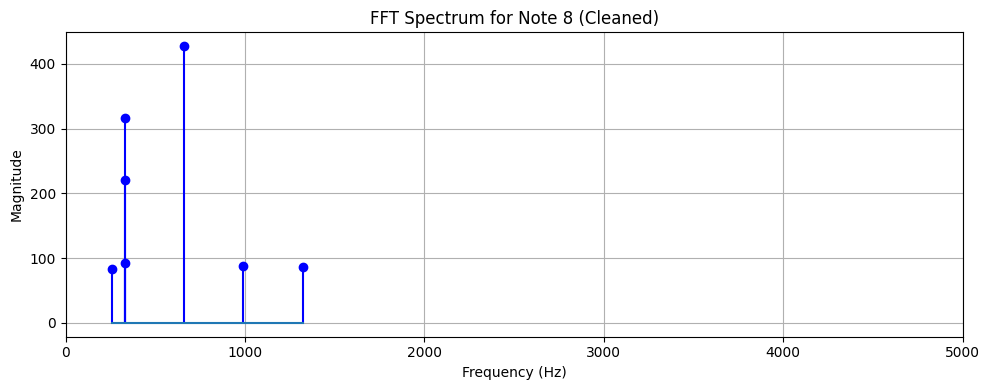

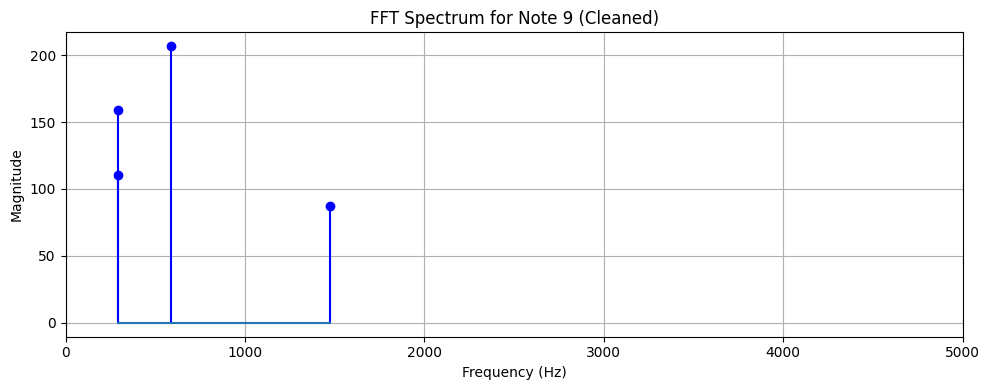

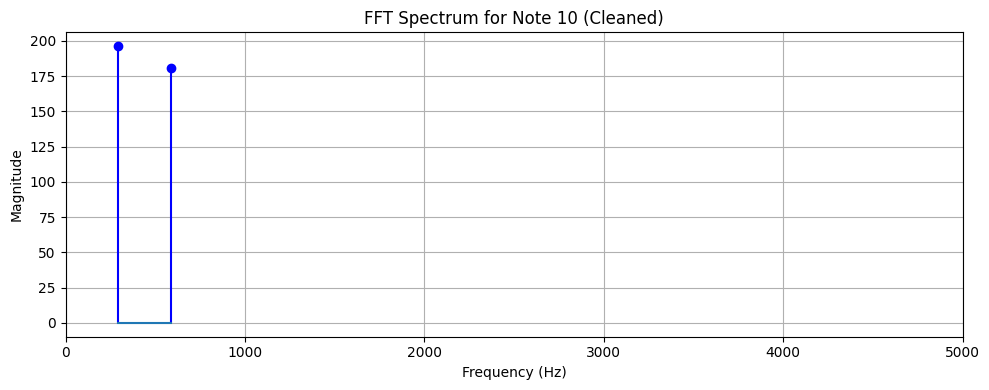

Selected Notes Frequencies: []
Lowest Frequency Closest Notes: []


In [28]:
# Perform FFT on each segment and compare dominant frequencies to the notes array
amplitude_threshold = 80  # Define the amplitude threshold

selected_notes = []  # List to store selected notes
lowest_frequency_notes = []  # List to store lowest frequency closest notes

for i, segment in enumerate(segments):
    # Compute FFT
    fft_result = np.fft.fft(segment)
    frequencies = np.fft.fftfreq(len(fft_result), d=1/sample_rate)
    magnitude = np.abs(fft_result)
    
    # Apply amplitude threshold
    fft_result[magnitude < amplitude_threshold] = 0
    magnitude = np.abs(fft_result)  # Recompute magnitude after cleanup
    
    # Keep only non-zero amplitudes and corresponding frequencies
    non_zero_indices = magnitude > 0
    frequencies = frequencies[non_zero_indices]
    magnitude = magnitude[non_zero_indices]
    
    # Plot the FFT spectrum
    plt.figure(figsize=(10, 4))
    plt.stem(frequencies[:len(frequencies)//2], magnitude[:len(magnitude)//2], 'b', markerfmt="o", basefmt="-")
    plt.title(f"FFT Spectrum for Note {i+1} (Cleaned)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.xlim(0, 5000)
    plt.tight_layout()
    plt.show()

# Print the selected notes and lowest frequency closest notes
print("Selected Notes Frequencies:", selected_notes)
print("Lowest Frequency Closest Notes:", lowest_frequency_notes)